# EDA

### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
from scipy.stats import zscore

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

### Read Required CSVs

In [2]:
data = pd.read_csv("combined.csv")
regions = pd.read_csv("SG_regions.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'combined.csv'

In [ ]:
# merge regions with data for column on region
data = pd.merge(data, regions, left_on='planning_area', right_on='PA_Workplace', how='left')
# merge CA into C
data['Region'] = data['Region'].replace({'CA':'C'})

In [ ]:
data = data.rename(columns={'Region':'region'})
data['region'].value_counts()

region
NE    36448
W     36206
C     28550
N     25099
E     24331
Name: count, dtype: int64

---

<font color = "orange">

## Possible features to investigate for modelling

</font>


**Structural Features**
- size: 'floor_area_sqft' ✅
- age: 'hdb_age' ✅ (note: check for linearity for modelling)
- height: 'storey_range' (but need to transform to numerical) ✅ (note: remember to log this for modelling)
- model: 'flat_model'<font color = "red">(categorical -> encode)</font> ✅

**Location Features**
- town: 'town' <font color = "red">(categorical -> encode using regions)</font> ✅
- mrt proximity: 'mrt_nearest_distance' (change to bool for mrt within 1km) ✅
- mall proximity: 'Mall_Within_500m' ✅
- pri sch proximity: 'pri_sch_nearest_distance' (change to bool for pri_sch within 1km) ✅
- if nearest MRT is also bus interchange: 'bus_interchange' ✅

**Transaction Features**
- year: 'Tranc_Year' ✅
- month: 'Tranc_Month' ✅

---

<font color = "orange">

## Structural Features

</font>

### Transform 'storey_range' from categorical to numerical
(*Note: for better resolution on storey, rather than expanding to multiple columns for a categorical column*)

In [ ]:
# for height ('storey_range')

def get_storey_mid(x):
    low, high = x.split(" TO ")
    return (int(low) + int(high)) / 2

data["storey_mid"] = data["storey_range"].apply(get_storey_mid)
data[["storey_mid", "storey_range"]]

,storey_mid,storey_range
0,11.00,10 TO 12
1,8.00,07 TO 09
2,14.00,13 TO 15
3,3.00,01 TO 05
4,2.00,01 TO 03
...,...,...
150629,5.00,04 TO 06
150630,5.00,04 TO 06
150631,11.00,10 TO 12
150632,8.00,07 TO 09


In [ ]:
data["storey_mid"].mean()

np.float64(8.284822815566207)

### Evaluate numerical columns as possible features
(*Note: size, age, height*)

In [ ]:
data['log_storey'] = np.log(data['storey_mid'])

In [ ]:
structural_cols = ['floor_area_sqft', 'hdb_age', 'storey_mid', 'log_storey']

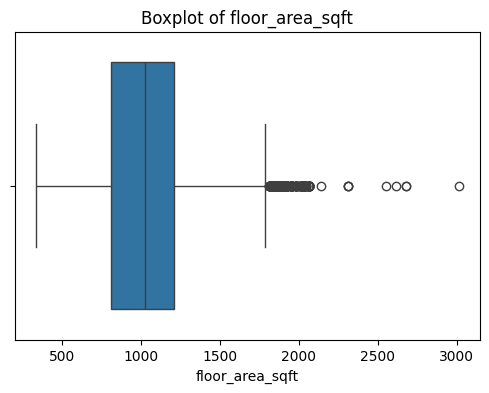

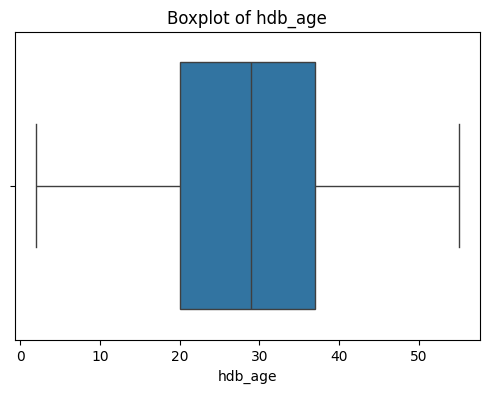

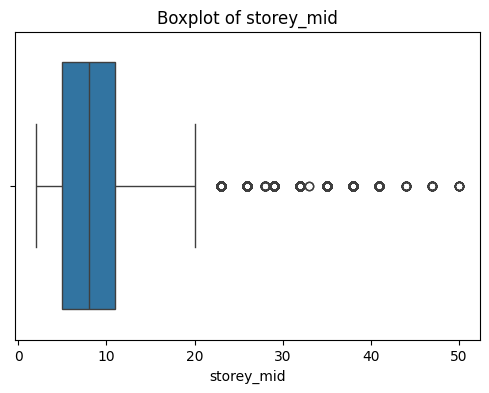

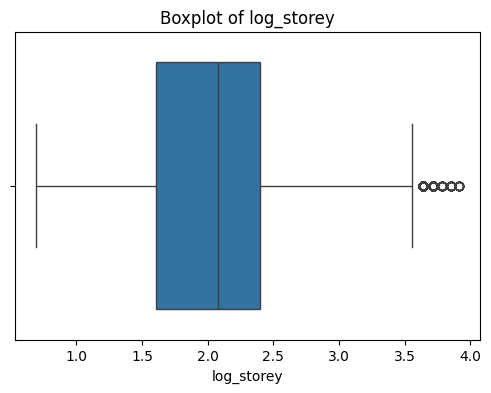

In [ ]:
# box plots
for col in structural_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
# examination on outliers

def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

for col in structural_cols:
    count, lower, upper = iqr_outliers(data, col)
    print(f"{col}: {count} outliers | Lower={lower:.2f} | Upper={upper:.2f}")

floor_area_sqft: 465 outliers | Lower=209.90 | Upper=1802.97
hdb_age: 0 outliers | Lower=-5.50 | Upper=62.50
storey_mid: 4173 outliers | Lower=-4.00 | Upper=20.00
log_storey: 394 outliers | Lower=0.43 | Upper=3.58


In [ ]:
# Z-score method to examine outliers
for col in structural_cols:
    z_scores = np.abs(zscore(data[col]))
    print(f"{col}: {(z_scores > 3).sum()} extreme values")

# presence of outliers for storey_mid -> heavy right skew -> will need to transform

floor_area_sqft: 418 extreme values
hdb_age: 0 extreme values
storey_mid: 2396 extreme values
log_storey: 0 extreme values


In [ ]:
data[structural_cols].skew()

# storey_mid is skewed heavily to the right, but after log(storey_mid), it is slightly to the left
# we should check if resale_price is skewed

floor_area_sqft    0.27
hdb_age           -0.20
storey_mid         1.56
log_storey        -0.35
dtype: float64

In [ ]:
data['resale_price'].skew()
# 1.08 is not catastrophic, but we should use log(resale_price) in the modelling
# data['log_price'] = np.log(data['resale_price'])

np.float64(1.0837585509131438)

Note: <font color = 'red'>**remember to create log(resale_price) for modelling**</font>

In [ ]:
data[structural_cols].describe()

,floor_area_sqft,hdb_age,storey_mid,log_storey
count,"150,634.00","150,634.00","150,634.00","150,634.00"
mean,"1,046.24",28.55,8.28,1.89
std,262.67,12.14,5.51,0.71
min,333.68,2.00,2.00,0.69
25%,807.30,20.00,5.00,1.61
50%,"1,022.58",29.00,8.00,2.08
75%,"1,205.57",37.00,11.00,2.40
max,"3,013.92",55.00,50.00,3.91


<Axes: xlabel='floor_area_sqft', ylabel='resale_price'>

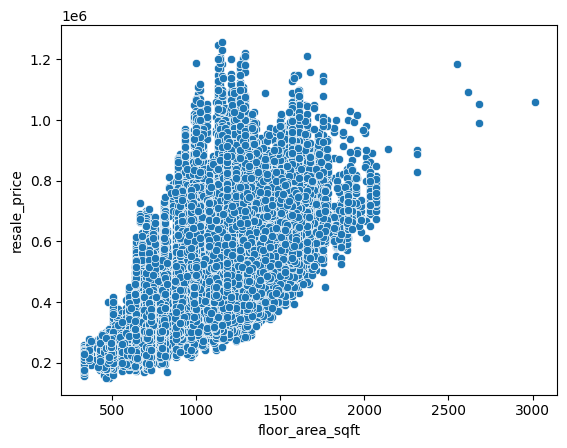

In [ ]:
sns.scatterplot(x='floor_area_sqft', y='resale_price', data=data)

<Axes: xlabel='hdb_age', ylabel='resale_price'>

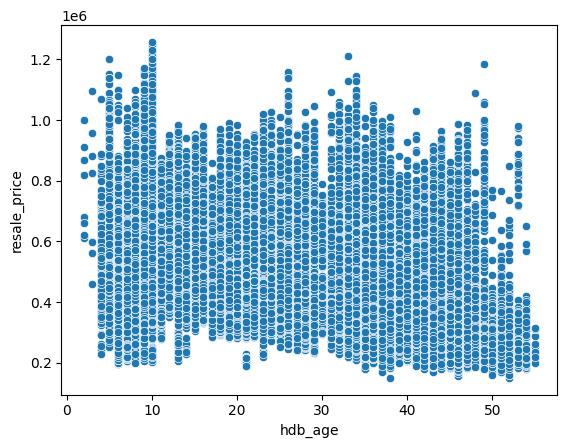

In [ ]:
sns.scatterplot(x='hdb_age', y='resale_price', data=data)

<Axes: xlabel='storey_mid', ylabel='resale_price'>

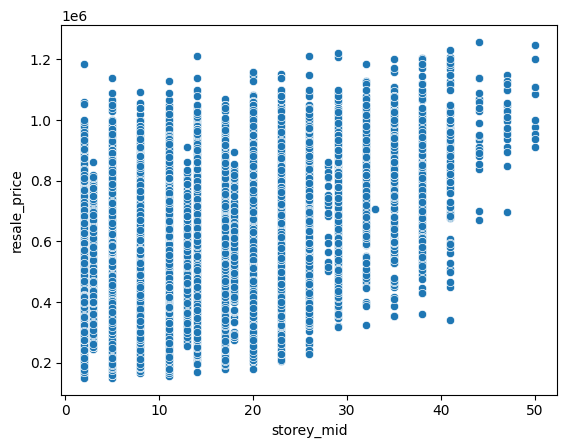

In [ ]:
sns.scatterplot(x='storey_mid', y='resale_price', data=data)

<Axes: xlabel='log_storey', ylabel='resale_price'>

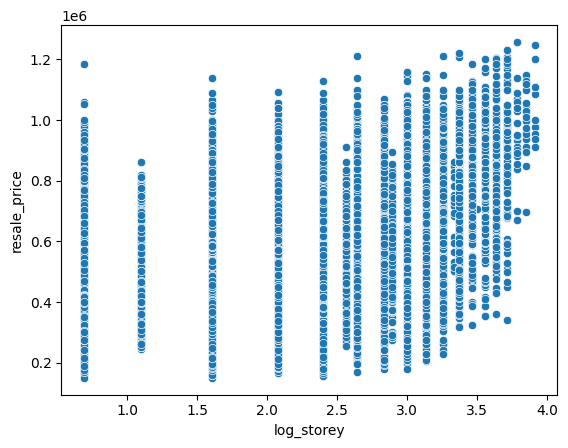

In [ ]:
sns.scatterplot(x='log_storey', y='resale_price', data=data)

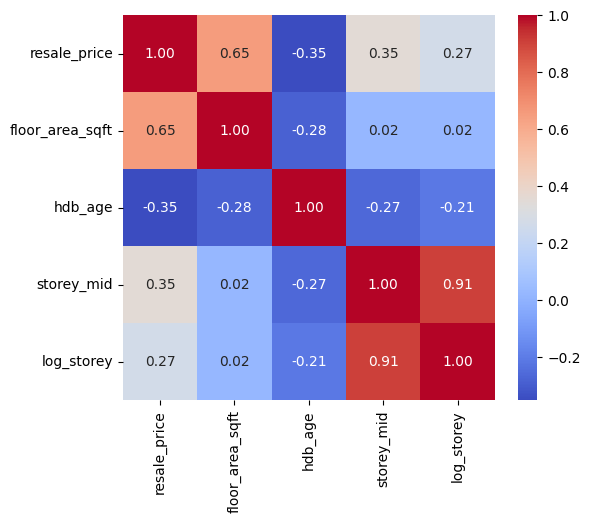

In [ ]:
# correlation matrix
corr = data[['resale_price'] + structural_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
# check VIF
X = data[structural_cols]
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

vif_df

,feature,VIF
0,const,44.21
1,floor_area_sqft,1.09
2,hdb_age,1.18
3,storey_mid,6.03
4,log_storey,5.87


### Prepare 'flat_model' as a possible feature
(*Need to reduce 20 values into a smaller number to minimise dimensionality*)

In [ ]:
print(data["flat_model"].unique())
# 20 types! Need to find a way to categorise them into a smaller number of groupings that is meaningful and relevant

print(data["flat_model"].value_counts(normalize=True) * 100)
# flat model representation is also quite imbalanced, we'll visualise

<StringArray>
[               'Model A',               'Improved',              'Apartment',
             'Simplified',         'New Generation',      'Premium Apartment',
               'Model A2',             'Maisonette',               'Standard',
                   'DBSS',                'Terrace',     'Model A-Maisonette',
                'Type S1', 'Premium Apartment Loft',          'Adjoined flat',
       'Multi Generation',                'Type S2',     'Premium Maisonette',
    'Improved-Maisonette',                 '2-room']
Length: 20, dtype: str
flat_model
Model A                  30.71
Improved                 25.57
New Generation           15.51
Premium Apartment        10.02
Simplified                4.81
Apartment                 4.04
Standard                  3.23
Maisonette                2.90
Model A2                  1.37
DBSS                      1.10
Model A-Maisonette        0.17
Adjoined flat             0.17
Type S1                   0.16
Type S2               

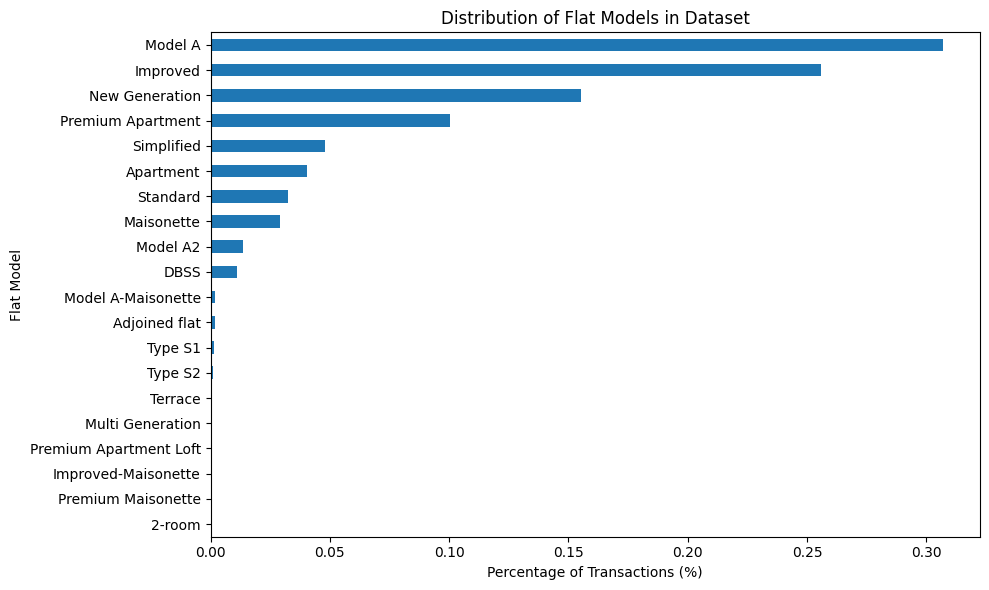

In [ ]:
plt.figure(figsize=(10, 6))
data["flat_model"].value_counts(normalize=True).sort_values().plot(kind='barh')

plt.xlabel("Percentage of Transactions (%)")
plt.ylabel("Flat Model")
plt.title("Distribution of Flat Models in Dataset")

plt.tight_layout()
plt.show()

In [ ]:
data.groupby("flat_model")["resale_price"].agg(['mean', 'median', 'count']).sort_values('mean')

,mean,median,count
flat_model,,,
2-room,"248,000.00","245,000.00",4
New Generation,"353,730.35","340,294.00",23366
Simplified,"358,441.78","350,000.00",7239
Model A2,"369,144.60","365,000.00",2064
Standard,"410,096.67","328,000.00",4867
Model A,"436,174.52","413,000.00",46261
Improved,"461,534.63","450,000.00",38514
Premium Apartment,"479,047.12","468,000.00",15091
Apartment,"620,324.98","605,000.00",6080


In [ ]:
# create smaller groupings for flat_model with based on mean prices and similarities

# 250-370K, clear separation from 410k+, older layouts
legacy = ['2-room', 'New Generation', 'Simplified', 'Model A2']

# 410-460K band, mass-market typical resale flats
core = ['Standard', 'Model A', 'Improved']

# non-maisonette but also viewed differently from core (note: can collapse into executive if req)
premium = ['Premium Apartment', 'Apartment']

# 674-698K, larger or multi-level, executive-era flats
executive = ['Maisonette', 'Improved-Maisonette', 'Adjoined flat', 'Model A-Maisonette']

# 749K-1M, rarer and most likely perceived as more prestigious
high_end = ['DBSS', 'Premium Maisonette', 'Multi Generation', 'Terrace', 'Premium Apartment Loft', 'Type S1', 'Type S2']

# caveat: it is very possible that this would be very correlated with size!

data["flat_model_tier"] = np.select(
    [
        data["flat_model"].isin(legacy),
        data["flat_model"].isin(core),
        data["flat_model"].isin(premium),
        data["flat_model"].isin(executive),
        data["flat_model"].isin(high_end),
    ],
    ["legacy", "core", "premium", "executive", "high_end"],
    default="other"
)

tier_order = ["legacy", "core", "premium", "executive", "high_end"]

data["flat_model_tier"] = pd.Categorical(
    data["flat_model_tier"],
    categories=tier_order,
    ordered=True
)

data["flat_model_tier"].value_counts(normalize=True)

flat_model_tier
core        0.60
legacy      0.22
premium     0.14
executive   0.03
high_end    0.01
Name: proportion, dtype: float64

In [ ]:
data.groupby("flat_model_tier")["resale_price"].agg(['mean', 'median', 'count'])

,mean,median,count
flat_model_tier,,,
legacy,"355,735.01","345,000.00",32673
core,"445,654.44","425,000.00",89642
premium,"519,620.04","510,000.00",21171
executive,"676,729.51","655,000.00",4905
high_end,"787,549.97","796,000.00",2243


In [ ]:
data.groupby("flat_model_tier")["floor_area_sqft"].mean()

# Interesting to note that high_end's mean is smaller than executive's mean, but high_end's mean price is ~100K more than executive
# the higher prices for high_end are not just due to size but possibly "prestige" (need to check if flat_model is significant in modelling)

flat_model_tier
legacy        849.65
core        1,040.06
premium     1,246.23
executive   1,584.74
high_end    1,091.47
Name: floor_area_sqft, dtype: float64

<Figure size 1000x600 with 0 Axes>

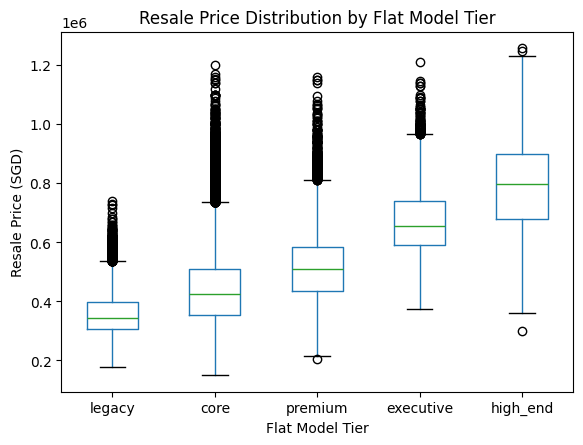

In [ ]:
plt.figure(figsize=(10, 6))

data.boxplot(
    column="resale_price",
    by="flat_model_tier",
    grid=False
)

plt.title("Resale Price Distribution by Flat Model Tier")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("Flat Model Tier")
plt.ylabel("Resale Price (SGD)")
plt.xticks(rotation=0)

plt.show()

<font color = "orange">

## Location Features

</font>

### Prepare 'town' as a possible feature
(*Need to reduce 26 values into a smaller number to minimise dimensionality*)

In [ ]:
print(data["town"].unique())
# 26 types! consider region?

print(data["town"].value_counts(normalize=True) * 100)
# 'town' representation is also quite imbalanced, we'll visualise


<StringArray>
['KALLANG/WHAMPOA',          'BISHAN',     'BUKIT BATOK',          'YISHUN',
         'GEYLANG',         'HOUGANG',           'BEDOK',        'SENGKANG',
        'TAMPINES',       'SERANGOON',     'BUKIT MERAH',   'BUKIT PANJANG',
       'WOODLANDS',     'JURONG WEST',       'TOA PAYOH',   'CHOA CHU KANG',
       'SEMBAWANG',      'ANG MO KIO',       'PASIR RIS',        'CLEMENTI',
         'PUNGGOL',     'JURONG EAST',    'CENTRAL AREA',      'QUEENSTOWN',
     'BUKIT TIMAH',   'MARINE PARADE']
Length: 26, dtype: str
town
JURONG WEST       7.60
WOODLANDS         7.52
SENGKANG          7.35
TAMPINES          6.97
YISHUN            6.67
BEDOK             6.01
PUNGGOL           5.17
HOUGANG           5.02
ANG MO KIO        4.59
CHOA CHU KANG     4.21
BUKIT MERAH       3.89
BUKIT PANJANG     3.77
BUKIT BATOK       3.73
TOA PAYOH         3.20
PASIR RIS         3.16
KALLANG/WHAMPOA   2.88
QUEENSTOWN        2.74
GEYLANG           2.65
SEMBAWANG         2.47
CLEMENTI          2.

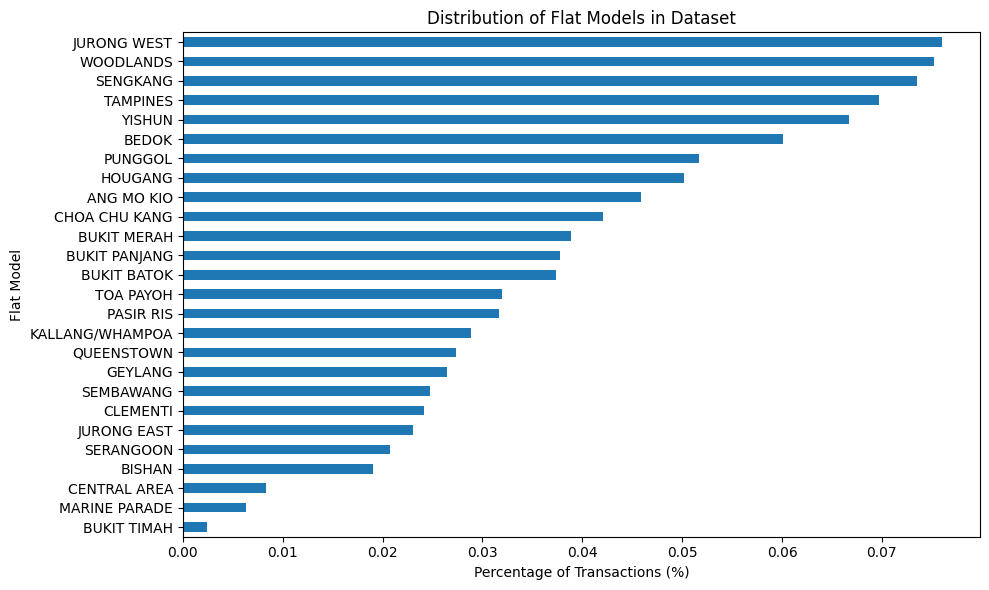

In [ ]:
plt.figure(figsize=(10, 6))
data["town"].value_counts(normalize=True).sort_values().plot(kind='barh')

plt.xlabel("Percentage of Transactions (%)")
plt.ylabel("Flat Model")
plt.title("Distribution of Flat Models in Dataset")

plt.tight_layout()
plt.show()

In [ ]:
data.groupby("town")["resale_price"].agg(['mean', 'median', 'count', 'sum']).sort_values('median')

,mean,median,count,sum
town,,,,
YISHUN,"375,553.96","357,000.00",10042,"3,771,312,846.00"
ANG MO KIO,"414,215.07","365,000.00",6908,"2,861,397,730.00"
BUKIT BATOK,"397,435.62","368,880.00",5623,"2,234,780,472.75"
GEYLANG,"429,782.14","378,000.00",3986,"1,713,111,628.00"
BEDOK,"419,066.23","380,000.00",9046,"3,790,873,144.00"
WOODLANDS,"403,015.41","390,000.00",11334,"4,567,776,703.64"
TOA PAYOH,"475,738.83","392,000.00",4817,"2,291,633,934.00"
JURONG EAST,"425,715.55","395,000.00",3470,"1,477,232,945.43"
CHOA CHU KANG,"413,041.81","401,100.00",6343,"2,619,924,177.76"


In [ ]:
data.groupby("region")["resale_price"].agg(['mean', 'median', 'count']).sort_values('mean')

,mean,median,count
region,,,
N,"393,413.78","380,000.00",25099
W,"420,555.74","405,000.00",36206
NE,"451,337.01","438,000.00",36448
E,"459,182.33","440,000.00",24331
C,"523,130.08","490,000.00",28550


<Figure size 1000x600 with 0 Axes>

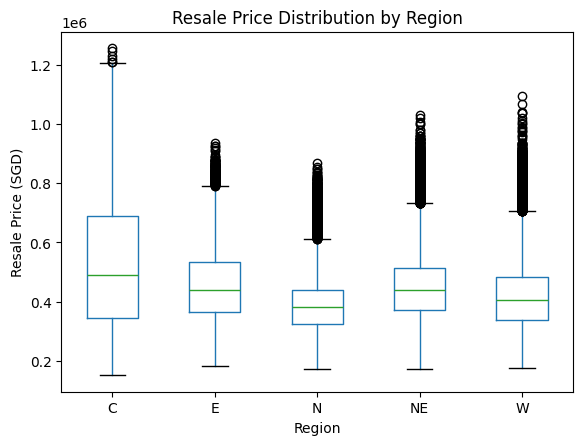

In [ ]:
plt.figure(figsize=(10, 6))

data.boxplot(
    column="resale_price",
    by="region",
    grid=False
)

plt.title("Resale Price Distribution by Region")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("Region")
plt.ylabel("Resale Price (SGD)")
plt.xticks(rotation=0)

cap = data['resale_price'].quantile(0.95)
data_plot = data.copy()
data_plot['resale_price_capped'] = data_plot['resale_price'].clip(upper=cap)

plt.show()

Observations on box plots by region:
- median for N is the lowest, followed by W, and then E & NE. C has the highest median
- C dominates with the highest upper tail (expected, flats are generally more expensive in the central region)
- Overlaps: there are varied flat types of various ages and storeys in this data. Acceptable.

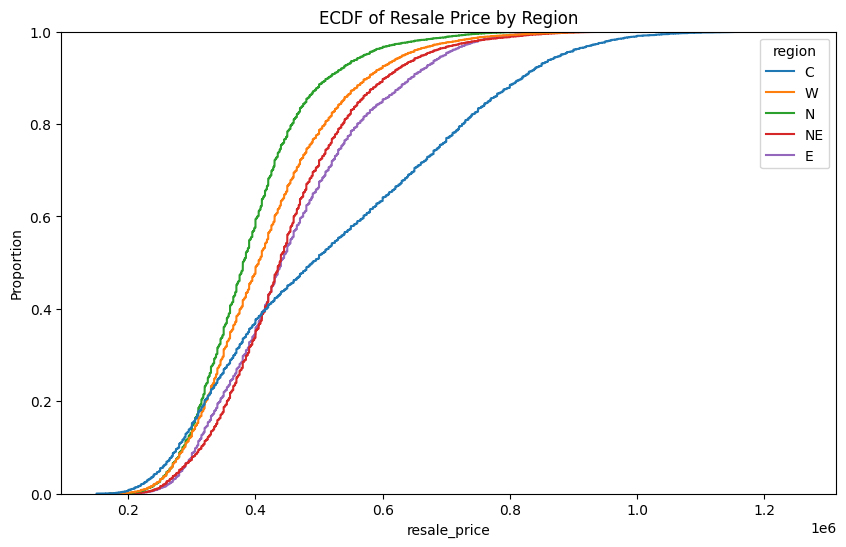

In [ ]:

plt.figure(figsize=(10,6))
sns.ecdfplot(data=data, x='resale_price', hue='region')
plt.title('ECDF of Resale Price by Region')
plt.show()

Observations:
- The Central region (blue curve) is the rightmost (after it crosses the other curves) -> for almost every percentile (after 0.4), Central Region requires higher price
- The North region (green curve) is the leftmost -> cheapest overall
- The Northeast and East regions (red and purple curves) are very close -> these two regions behave very similarly in resale price distribution (<font color = 'red'>might not need to separate them</font>)
- The West region is between the North and Northeast/East

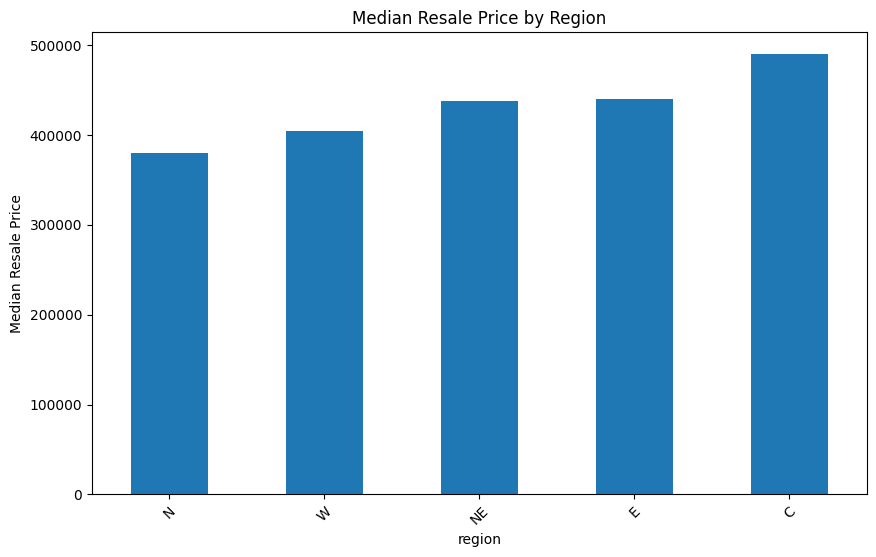

In [ ]:
median_prices = (
    data.groupby('region')['resale_price']
    .median()
    .sort_values()
)

plt.figure(figsize=(10,6))
median_prices.plot(kind='bar')
plt.title('Median Resale Price by Region')
plt.ylabel('Median Resale Price')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ANOVA

groups = [group['resale_price'].values
          for name, group in data.groupby('region')]

f_stat, p_val = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_val}")

F-statistic: 3549.1679915789273
P-value: 0.0


In [ ]:
# Linear regression where dependent variable is resale_price, independent variable is region
model = smf.ols('resale_price ~ C(region)', data=data).fit() # C() is used because region is categorical
anova_table = sm.stats.anova_lm(model, typ=2)

eta_sq = anova_table['sum_sq']['C(region)'] / anova_table['sum_sq'].sum()
print("Eta-squared:", eta_sq)

Eta-squared: 0.08613143691121711


**Observations:**
- Eta-square value of 0.08 means that *region* can explain roughly 8–9% of resale price variation on its own. Even though the price distributions overlap visually (from the boxplots), there is a consistent pattern to the change in resale prices by location.
- This is particularly with Central being consistently right-shifted and North being lowest (from the ECDF curves).
- In fact, the change from low to high is: N-> W -> NE/E -> C (highest)
- Region functions as a <font color = 'red'>moderate but meaningful</font> indicator of people's willingness to pay for a premium (e.g. it is very likely from the data that the central region commands a higher premium).

### Prepare "near_mrt" feature

In [ ]:
# for mrt proximity 'mrt_nearest_distance'

def is_near_mrt(dist):
    if dist <= 1000: # we assume that 1km to the mrt is a good range
        return 1
    else:
        return 0

data["near_mrt"] = data['mrt_nearest_distance'].apply(is_near_mrt)

In [ ]:
data[["near_mrt", "mrt_nearest_distance"]]

,near_mrt,mrt_nearest_distance
0,1,330.08
1,1,903.66
2,0,"1,334.25"
3,1,907.45
4,1,412.34
...,...,...
150629,1,713.68
150630,1,239.77
150631,1,669.28
150632,1,502.03


### Prepare "near_pri_sch" as a feature

In [ ]:
# for pri sch proximity ('pri_sch_nearest_distance')

def is_near_pri_sch(dist):
    if dist <= 1000: # 1 km affords parents higher-priority for entry
        return 1
    else:
        return 0

data["near_pri_sch"] = data["pri_sch_nearest_distance"].apply(is_near_pri_sch)

In [ ]:
data[["near_pri_sch", "pri_sch_nearest_distance"]]

,near_pri_sch,pri_sch_nearest_distance
0,0,"1,138.63"
1,1,415.61
2,1,498.85
3,1,389.52
4,1,401.20
...,...,...
150629,1,418.98
150630,1,136.30
150631,1,512.63
150632,1,787.25


### Evaluate numerical columns as possible features
(*Note: near mrt, near pri sch, mall within 500m, bus interchange which is also mrt*)

In [ ]:
# 'bus_interchange' is boolean, convert to int
data['bus_interchange'] = data['bus_interchange'].astype(int)

In [ ]:
location_cols = ['near_mrt', 'near_pri_sch', 'Mall_Within_500m', 'bus_interchange']
data[location_cols].describe()

,near_mrt,near_pri_sch,Mall_Within_500m,bus_interchange
count,"150,634.00","150,634.00","150,634.00","150,634.00"
mean,0.77,0.98,0.49,0.55
std,0.42,0.15,0.73,0.50
min,0.00,0.00,0.00,0.00
25%,1.00,1.00,0.00,0.00
50%,1.00,1.00,0.00,1.00
75%,1.00,1.00,1.00,1.00
max,1.00,1.00,6.00,1.00


In [ ]:
for col in location_cols:
    print(data.groupby(col)['resale_price'].agg(['mean','median','count']))

    # near_mrt strong contender because median differ by 20K, recommend to keep
    # near_pri_sch very imbalanced by counts, means also very close, recommend to drop after checking VIF
    # Mall_Within_500m maybe collapse to 0, 1, 2+ due to imbalance in counts, differences in mean/median promising
    # bus_interchange keep for now, but I suspect it is collinear with near_mrt

               mean     median   count
near_mrt                              
0        426,854.61 415,000.00   35378
1        456,008.63 425,000.00  115256
                   mean     median   count
near_pri_sch                              
0            440,568.17 400,000.00    3295
1            449,353.68 421,000.00  147339
                       mean     median  count
Mall_Within_500m                             
0                441,467.98 412,000.00  92789
1                456,016.34 430,000.00  46732
2                482,860.27 458,000.00   7557
3                474,800.45 444,000.00   2842
4                529,778.49 490,000.00    547
5                568,096.08 500,000.00    143
6                653,370.33 654,000.00     24
                      mean     median  count
bus_interchange                             
0               448,760.91 410,000.00  68333
1               449,494.11 430,000.00  82301


In [ ]:
data[['near_mrt','resale_price']].corr()

# maybe we need to relook at changing the continuous distance to mrt to binary 1/0

,near_mrt,resale_price
near_mrt,1.00,0.09
resale_price,0.09,1.00


In [ ]:
data[['mrt_nearest_distance','resale_price']].corr()

,mrt_nearest_distance,resale_price
mrt_nearest_distance,1.00,-0.13
resale_price,-0.13,1.00


In [ ]:
data.groupby('Mall_Within_500m')['resale_price'].median()

Mall_Within_500m
0   412,000.00
1   430,000.00
2   458,000.00
3   444,000.00
4   490,000.00
5   500,000.00
6   654,000.00
Name: resale_price, dtype: float64

In [ ]:
data[location_cols].corr()

,near_mrt,near_pri_sch,Mall_Within_500m,bus_interchange
near_mrt,1.00,0.15,0.06,-0.18
near_pri_sch,0.15,1.00,0.01,0.03
Mall_Within_500m,0.06,0.01,1.00,0.19
bus_interchange,-0.18,0.03,0.19,1.00


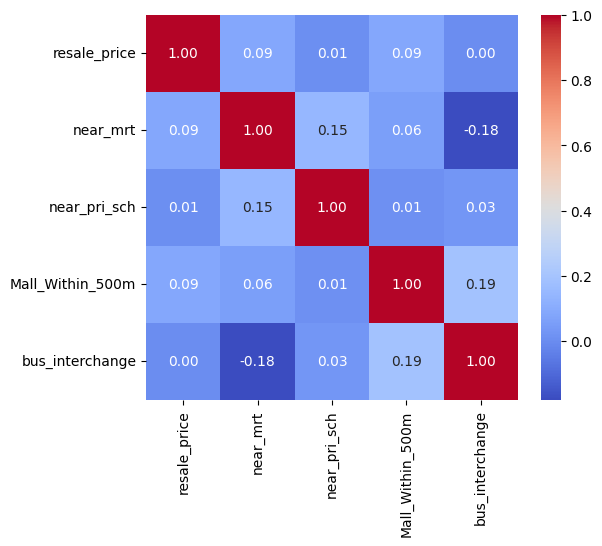

In [ ]:
# correlation matrix
corr = data[['resale_price'] + location_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### Observations

- Location features are observed to be weakly correlated with resale_price, but that is not a deal breaker for now. We can let structural features take the primary stage (especially floor_area_sqft) but some location features can be added
- Perhaps 'binarising' near_mrt resulted in collapsing the effect that distance_to_mrt had.

<font color = "orange">

## Evaluating Transaction Features

</font>

In [ ]:
trans_cols = ['Tranc_Year', 'Tranc_Month']

<Axes: xlabel='Tranc_Year', ylabel='resale_price'>

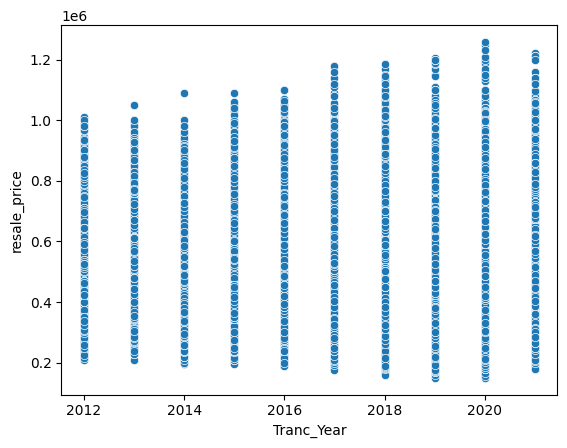

In [ ]:
sns.scatterplot(x='Tranc_Year', y='resale_price', data=data)

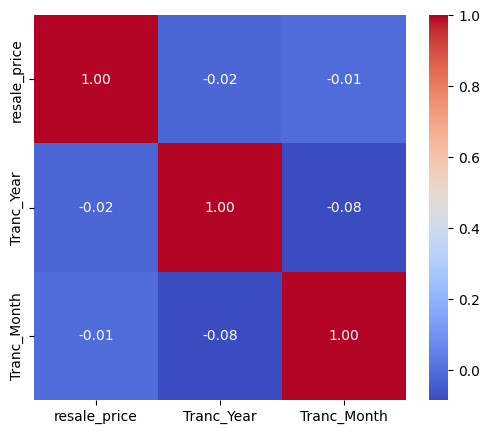

In [ ]:
# correlation matrix
corr = data[['resale_price'] + trans_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

<font color = "orange">

## Export relevant columns for modelling

</font>

**Target**
- resale_price

**Primary Features**
- floor_area_sqft
- remaining_lease
- region
- mrt_nearest_distance
- mid

**Secondary Features**
- town
- Tranc_Year
- flat_model_tier
- bto_launched
- mop_flats

In [ ]:
data['remaining_lease'] = 99 - data['hdb_age']

In [ ]:
target = ['resale_price']

primary_features = ['floor_area_sqft', 'remaining_lease', 'region', 'mrt_nearest_distance', 'mid']

secondary_features = ['town', 'Tranc_Year', 'flat_model_tier', 'bto_launched', 'mop_flats']

In [ ]:
modelling = data[target + primary_features + secondary_features]

In [ ]:
modelling.to_csv('cleaned_data3.csv', index=False)

<font color = "orange">

## Export relevant columns for visualisation

</font>

**Useful for non-technical audience**
- planning_area
- flat_type
- storey_range
- flat_model
- lease_commence_date
- max_floor_lvl

In [ ]:
additional = ['planning_area', 'flat_type', 'storey_range',
              'flat_model', 'lease_commence_date', 'max_floor_lvl']

In [ ]:
visualisation = data[target + primary_features + secondary_features + additional]

In [ ]:
visualisation.to_csv('for_visualisation.csv', index=False)

This notebook performs exploratory data analysis on the cleaned HDB resale dataset, examining the distribution of resale prices, analysing numerical and categorical feature behaviour, evaluating correlations and potential multicollinearity, and identifying meaningful relationships between property characteristics and price. The analysis establishes key predictors (e.g., floor area, lease remaining, accessibility) and informs subsequent modelling decisions such as transformation and feature selection.